In [1]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")
sys.path.append(r'd:\repo\XAI_Projekt-1')
sys.path.append(r'd:\repo\XAI_Projekt-1\src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split

from src.utils import (
    save_model,
    load_model,
    load_train_test_data,
    calibration_metrics_dict,
    expected_calibration_error,
    reliability_diagram,
)
from src.constants import (
    RANDOM_STATE, TRAIN_PATH, TEST_PATH, TUNED_LR_MODEL_PATH, TUNED_RF_MODEL_PATH,
    CALIBRATED_LR_MODEL_PATH, CALIBRATED_RF_MODEL_PATH
)
# Load data
X_train, X_test, y_train, y_test = load_train_test_data(
    train_path=TRAIN_PATH,
    test_path=TEST_PATH,
)

# split test set into validation and test for calibration evaluation
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=RANDOM_STATE, stratify=y_test
)

In [2]:
# Load tuned Logistic Regression model
model = load_model(TUNED_LR_MODEL_PATH)

# Get predicted probabilities
p_val = model.predict_proba(X_val)[:, 1]
p_test = model.predict_proba(X_test)[:, 1]

print("VAL:", calibration_metrics_dict(y_val, p_val))
print("TEST:", calibration_metrics_dict(y_test, p_test))

VAL: {'AUC': 0.73741353646791, 'Recall': 0.6666666666666666, 'Brier': 0.22523110379770503, 'LogLoss': 0.6389478135133574}
TEST: {'AUC': 0.7530841799709725, 'Recall': 0.8076923076923077, 'Brier': 0.226174828152682, 'LogLoss': 0.6441728069583746}


ECE: 0.4023


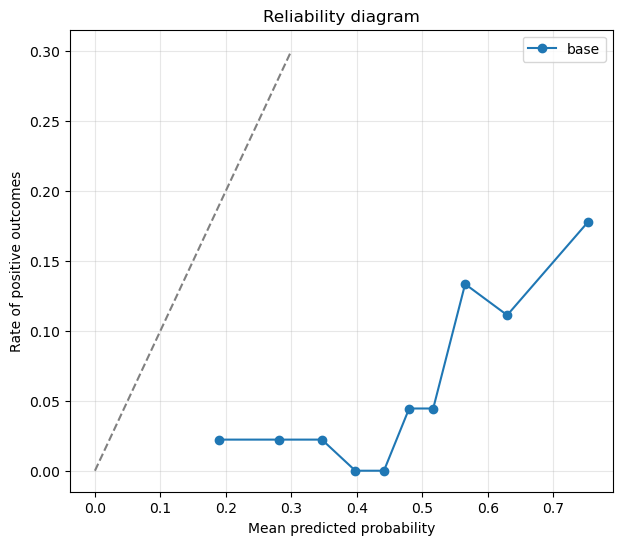

In [3]:
ece_base = expected_calibration_error(y_test.values, p_test)
print(f"ECE: {ece_base:.4f}")

fig, ax = plt.subplots(figsize=(7,6))
reliability_diagram(ax, y_test, p_test, label="base")
ax.legend()
plt.show()

Sigmoid: {'AUC': 0.7530841799709725, 'Recall': 0.0, 'Brier': 0.050988557403419316, 'LogLoss': 0.19836106124341227}
Isotonic: {'AUC': 0.7005170537010159, 'Recall': 0.15384615384615385, 'Brier': 0.051130059117494325, 'LogLoss': 0.4088914617362088}
ECE sigmoid: 0.0208
ECE isotonic: 0.0089


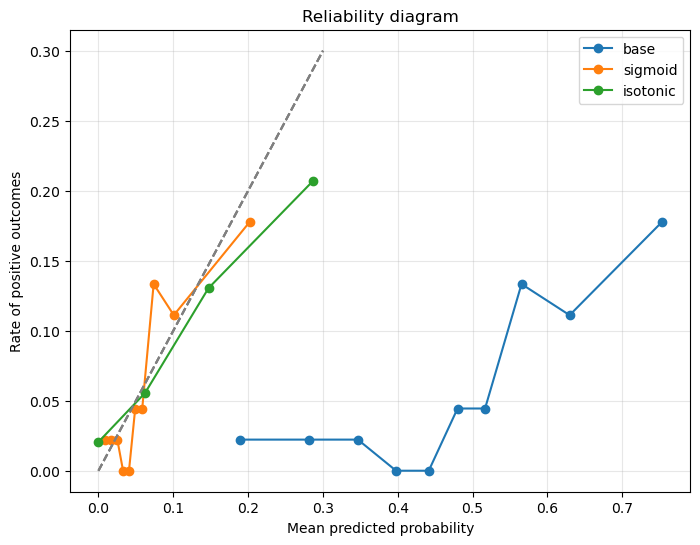

In [4]:
sig = CalibratedClassifierCV(estimator=model, method="sigmoid", cv="prefit")
sig.fit(X_val, y_val)

iso = CalibratedClassifierCV(estimator=model, method="isotonic", cv="prefit")
iso.fit(X_val, y_val)

p_test_sig = sig.predict_proba(X_test)[:,1]
p_test_iso = iso.predict_proba(X_test)[:,1]

print("Sigmoid:", calibration_metrics_dict(y_test, p_test_sig))
print("Isotonic:", calibration_metrics_dict(y_test, p_test_iso))

ece_sig = expected_calibration_error(y_test.values, p_test_sig)
ece_iso = expected_calibration_error(y_test.values, p_test_iso)

print(f"ECE sigmoid: {ece_sig:.4f}")
print(f"ECE isotonic: {ece_iso:.4f}")

fig, ax = plt.subplots(figsize=(8,6))
reliability_diagram(ax, y_test, p_test, label="base")
reliability_diagram(ax, y_test, p_test_sig, label="sigmoid")
reliability_diagram(ax, y_test, p_test_iso, label="isotonic")
ax.legend()
plt.show()

Dla regresji logistycznej wybieramy kalibrację sigmoid. Choć isotonic osiągnęła dokładniejszą kalibrację (pod względem ECE), to jednak znacząco obniżyła ogólną zdolność predykcyjną modelu (spadek AUC z 0.75 do 0.70).

In [5]:
save_model(sig, CALIBRATED_LR_MODEL_PATH)

In [6]:
# Load tuned Random Forest model
model = load_model(TUNED_RF_MODEL_PATH)

# Get predicted probabilities
p_val = model.predict_proba(X_val)[:, 1]
p_test = model.predict_proba(X_test)[:, 1]

print("VAL:", calibration_metrics_dict(y_val, p_val))
print("TEST:", calibration_metrics_dict(y_test, p_test))

VAL: {'AUC': 0.6882059364328867, 'Recall': 0.0, 'Brier': 0.0554403986554524, 'LogLoss': 0.2160799503307976}
TEST: {'AUC': 0.7733127721335269, 'Recall': 0.038461538461538464, 'Brier': 0.04970188282960385, 'LogLoss': 0.19269126427787928}


ECE: 0.0250


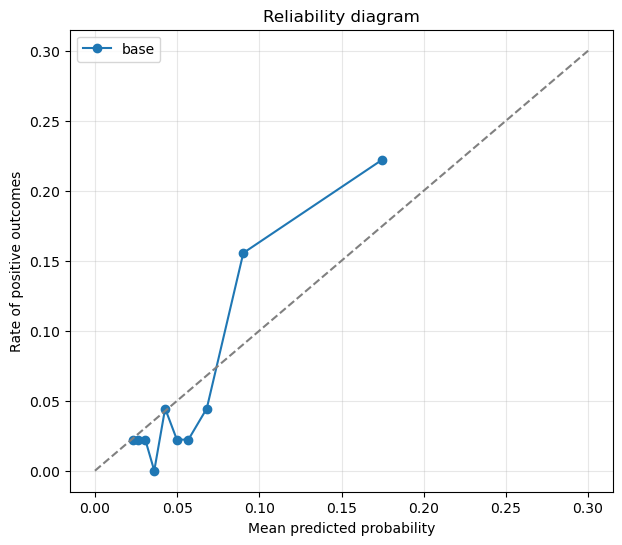

In [7]:
ece_base = expected_calibration_error(y_test.values, p_test)
print(f"ECE: {ece_base:.4f}")

fig, ax = plt.subplots(figsize=(7,6))
reliability_diagram(ax, y_test, p_test, label="base")
ax.legend()
plt.show()

Sigmoid: {'AUC': 0.7733127721335269, 'Recall': 0.07692307692307693, 'Brier': 0.05048041627710198, 'LogLoss': 0.19845600221354662}
Isotonic: {'AUC': 0.7581186502177069, 'Recall': 0.0, 'Brier': 0.05208690086687267, 'LogLoss': 0.2712215490128997}
ECE sigmoid: 0.0317
ECE isotonic: 0.0227


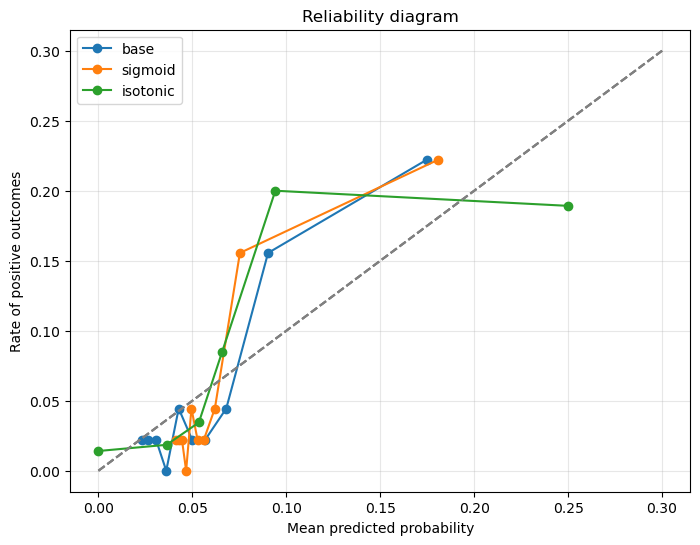

In [8]:
sig = CalibratedClassifierCV(estimator=model, method="sigmoid", cv="prefit")
sig.fit(X_val, y_val)

iso = CalibratedClassifierCV(estimator=model, method="isotonic", cv="prefit")
iso.fit(X_val, y_val)

p_test_sig = sig.predict_proba(X_test)[:,1]
p_test_iso = iso.predict_proba(X_test)[:,1]

print("Sigmoid:", calibration_metrics_dict(y_test, p_test_sig))
print("Isotonic:", calibration_metrics_dict(y_test, p_test_iso))

ece_sig = expected_calibration_error(y_test.values, p_test_sig)
ece_iso = expected_calibration_error(y_test.values, p_test_iso)

print(f"ECE sigmoid: {ece_sig:.4f}")
print(f"ECE isotonic: {ece_iso:.4f}")

fig, ax = plt.subplots(figsize=(8,6))
reliability_diagram(ax, y_test, p_test, label="base")
reliability_diagram(ax, y_test, p_test_sig, label="sigmoid")
reliability_diagram(ax, y_test, p_test_iso, label="isotonic")
ax.legend()
plt.show()

Dla Random Forest także wybierzemy kalibrację sigmoid, ze względu na większe AUC oraz logloss. Zapisujemy skalibrowany model.

In [9]:
save_model(sig, CALIBRATED_RF_MODEL_PATH)